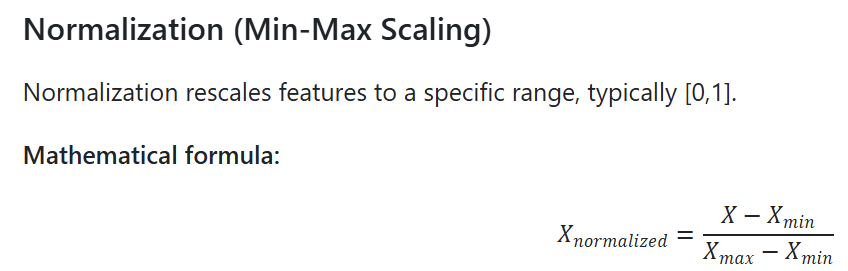

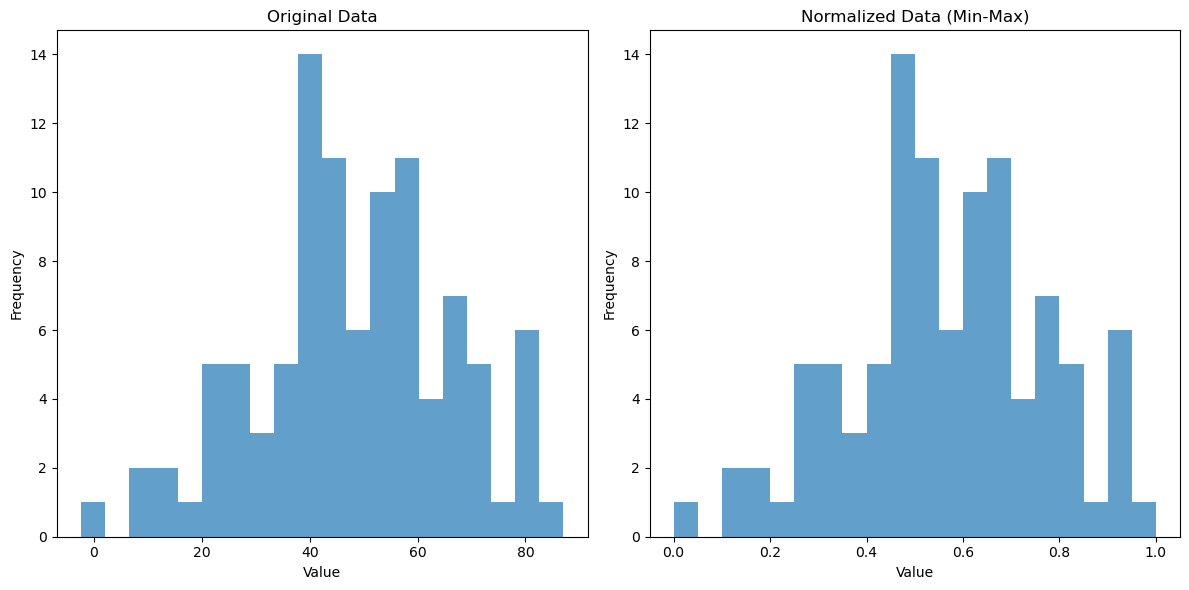

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Generate sample data
np.random.seed(42)
original_data = np.random.normal(loc=50, scale=20, size=100)

# Apply normalization
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(original_data.reshape(-1, 1)).flatten()

# Visualization
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(original_data, bins=20, alpha=0.7)
plt.title('Original Data')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(normalized_data, bins=20, alpha=0.7)
plt.title('Normalized Data (Min-Max)')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

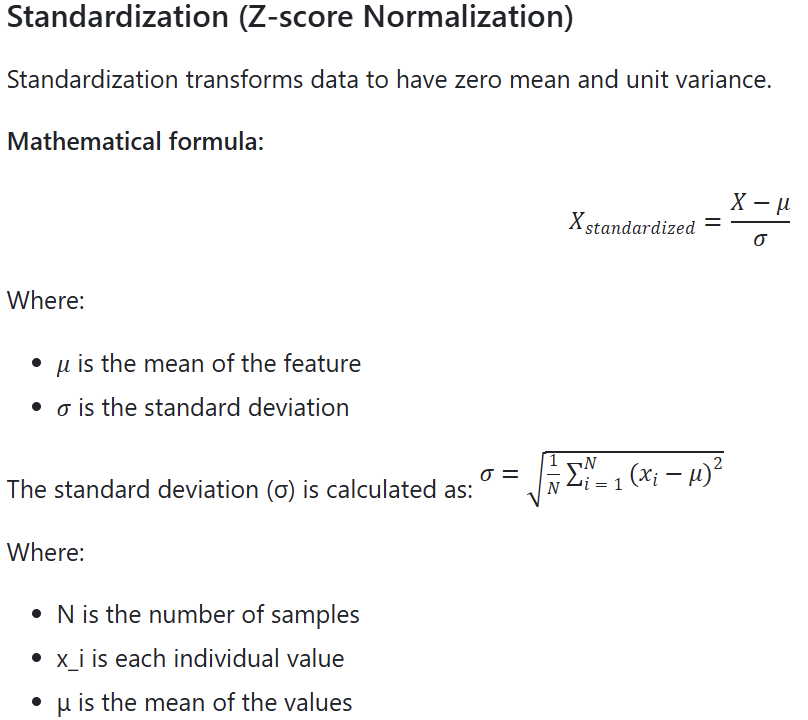

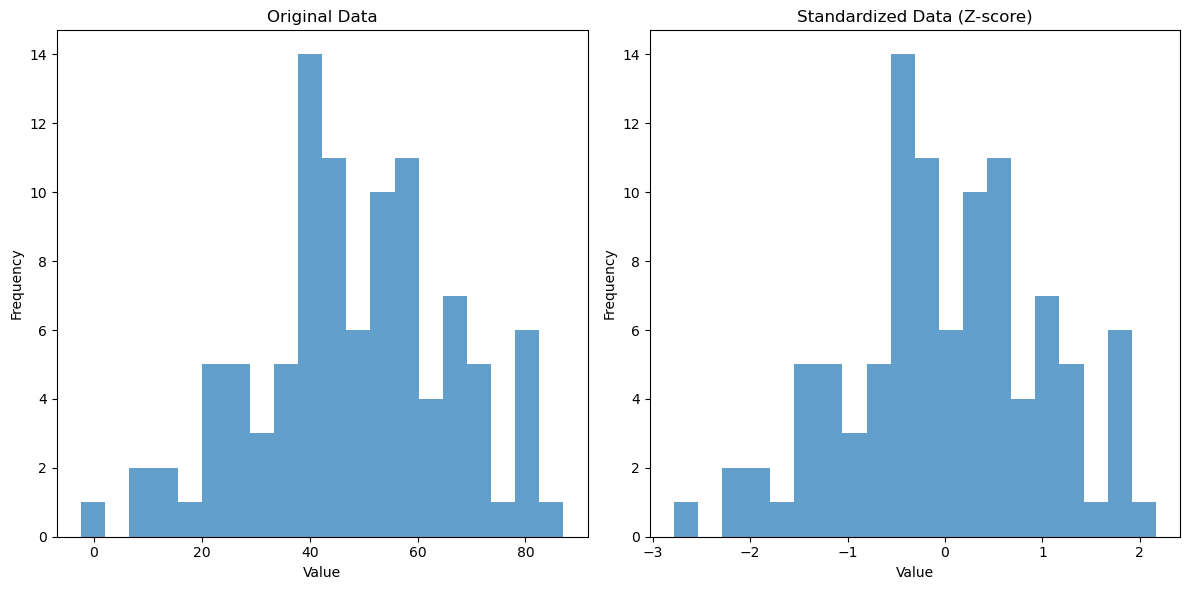

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Generate sample data
np.random.seed(42)
original_data = np.random.normal(loc=50, scale=20, size=100)

# Apply standardization
scaler = StandardScaler()
standardized_data = scaler.fit_transform(original_data.reshape(-1, 1)).flatten()

# Visualization
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(original_data, bins=20, alpha=0.7)
plt.title('Original Data')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(standardized_data, bins=20, alpha=0.7)
plt.title('Standardized Data (Z-score)')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

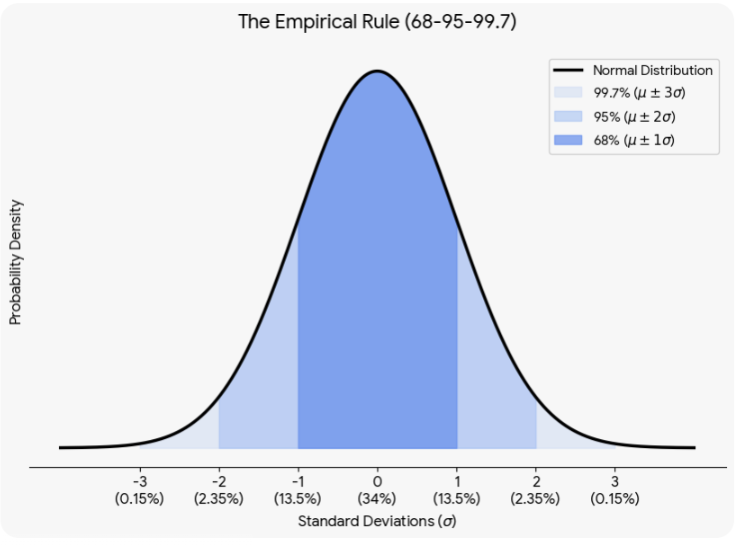

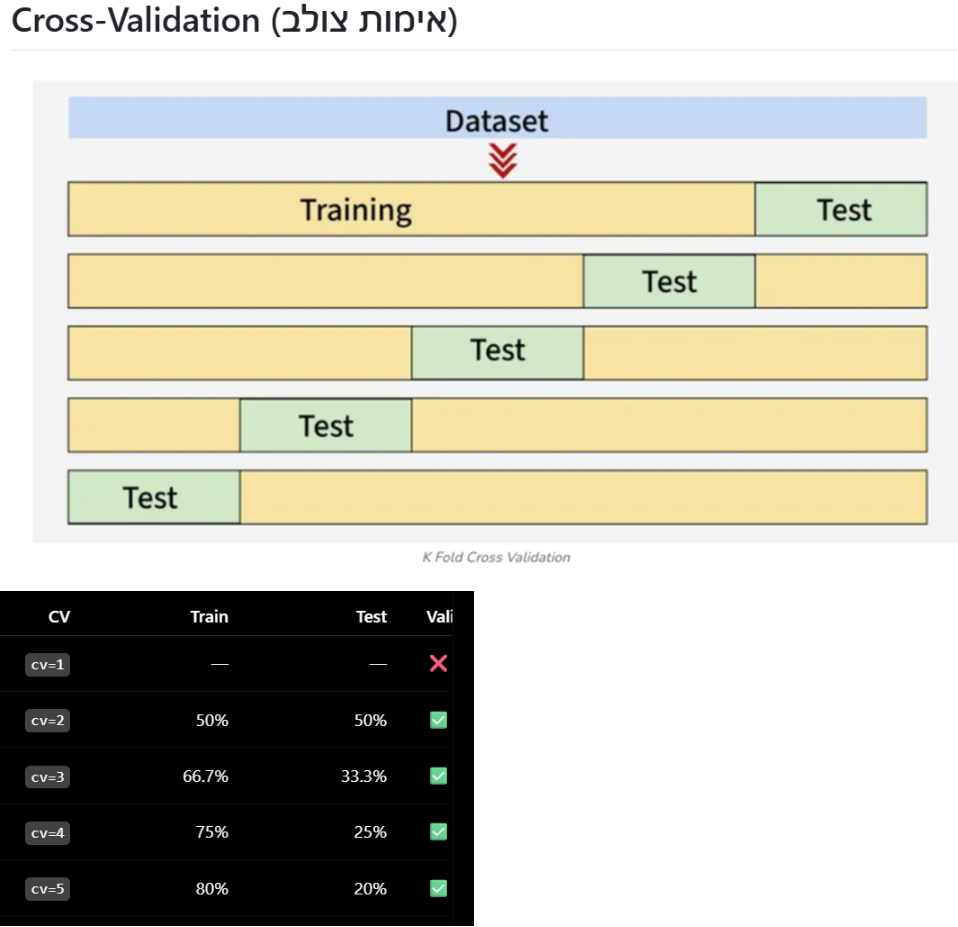

--- Cross-Validation Results ---
k = 1 | Average Accuracy: 1.00
k = 2 | Average Accuracy: 1.00
k = 3 | Average Accuracy: 0.78
k = 4 | Average Accuracy: 0.44
k = 5 | Average Accuracy: 0.44
k = 6 | Average Accuracy: 0.33

Best K: 1


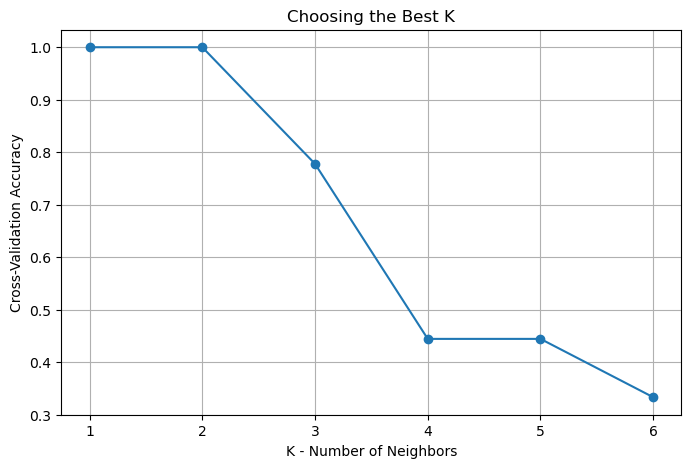

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score, LeaveOneOut

# Fruit data
colors = np.array([200, 50, 220, 240, 250, 230, 30, 40, 20])
sizes = np.array([7, 7, 6, 9, 8, 9, 12, 13, 11])
weights = np.array([150, 160, 140, 170, 165, 180, 120, 130, 115])

fruit_types = np.array([
    'apple', 'apple', 'apple',
    'orange', 'orange', 'orange',
    'banana', 'banana', 'banana'
])

# Create feature matrix
X = np.column_stack((colors, sizes, weights))
y = fruit_types

# Normalize data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Test different K values
k_range = [1, 2, 3, 4, 5, 6]
cv_scores = []

# 9 samples:
# Each iteration = 8 training + 1 testing
# Approximately 90% / 10%
loo = LeaveOneOut()

print("--- Cross-Validation Results ---")

for k in k_range:

    model = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        model,
        X_scaled,
        y,
        cv=3,
        scoring='accuracy'
    )

    mean_score = scores.mean()
    cv_scores.append(mean_score)

    print(f"k = {k} | Average Accuracy: {mean_score:.2f}")


# Train final model using best K
best_k = k_range[np.argmax(cv_scores)]

print(f"\nBest K: {best_k}")

model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_scaled, y)

# Plot K vs Cross-Validation Accuracy
plt.figure(figsize=(8, 5))

plt.plot(k_range, cv_scores, marker='o')

plt.xlabel("K - Number of Neighbors")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Choosing the Best K")

plt.xticks(k_range)
plt.grid(True)

plt.show()